In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime , timedelta
import pandas as pd
import matplotlib.dates as mdates
import io
from PIL import Image
from folium.plugins import HeatMap
import folium
import os
import colorgram 
import kaleido
import plotly.express as px
from PIL import Image
from io import BytesIO
import requests

figures_path = os.path.join('figures')

monthly_metrics_path = 'data/monthly_metrics.csv'
observations_path = 'data/observations.csv'
new_species_path = 'data/new_species_photo.csv'
taxon_counts_path = 'data/taxon_counts.csv'


palette = ['#2b2e4f', '#f85532', '#fe5631', '#f95532', '#2a2e4f']

# 1.Graficación y muestra de métricas principales

1.1. número de observaciones, número de observadores, identificadores y especies
1.2. variación respecto al mes anterior

Estas métricas se mostrarán en forma de tabla debido a que es la mejor opción disponible 

# 2.Graficación evolución mensual de las metricas principales

Gráficos por observaciones, observadores, idntificadores y especies

In [2]:
df_monthly = pd.read_csv('data\monthly_metrics.csv')

In [3]:
df_monthly

,month,observations,observers,identifiers,species
0,2022-01,0,0,0,0
1,2022-02,0,0,0,0
2,2022-03,0,0,0,0
3,2022-04,0,0,0,0
4,2022-05,0,0,0,0
5,2022-06,96,4,9,41
6,2022-07,32,5,6,12
7,2022-08,146,6,7,46
8,2022-09,146,8,8,55
9,2022-10,87,3,12,58


In [8]:
import plotly.express as px
import pandas as pd


fig = px.bar(df_monthly, 
             x='month', 
             y='observers',
             text='observers',  # Esto añade los valores como texto
             #title='Observaciones por Mes',
             #labels={'month': 'Mes', 'observations': 'Número de Observaciones'},
             )  

fig.update_traces(
    #texttemplate='%{text}',  # Formato del texto (puedes usar '%{text:.0f}' para números enteros)
    marker_color='#f85532',
    textposition='outside'
    )  # Posición fuera de las barras

# Personalizar el diseño si lo deseas
fig.update_layout(
    title_x=0.5,  # Centrar el título
    #xaxis_title="Mes",
    #yaxis_title="Observaciones",
    template="plotly_white"  # Puedes cambiar el template (plotly, plotly_white, plotly_dark, etc.)
)

# Mostrar el gráfico
fig.show()

In [4]:
def plot_monthly_metrics(df_monthly, column:str):

    fig = px.bar(df_monthly, 
                x='month', 
                y=column,
                text=column,  # Esto añade los valores como texto
                title=f'Evolución mensual de {column}',
                #labels={'month': 'Mes', 'observations': 'Número de Observaciones'},
                )  

    fig.update_traces(
        #texttemplate='%{text}',  # Formato del texto (puedes usar '%{text:.0f}' para números enteros)
        marker_color='#f85532',
        textposition='outside'
        )  # Posición fuera de las barras

    # Personalizar el diseño si lo deseas
    fig.update_layout(
        title_x=0.5,  # Centrar el título
        #xaxis_title="Mes",
        #yaxis_title="Observaciones",
        template="plotly_white"  # Puedes cambiar el template (plotly, plotly_white, plotly_dark, etc.)
    )

    fig.write_image(f"{figures_path}/{column}_monthly_plot_.png")

    # Mostrar el gráfico
    fig.show()

In [ ]:
plot_monthly_metrics(df_monthly, 'species')

In [1]:
df_monthly.head()

NameError: name 'df_monthly' is not defined

2.1.Grafico observaciones

In [ ]:
def get_observations_month():
    
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['observations'],
        palette=palette
    )

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height + height * 0.0010,             
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f" Observations in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of observations")
    plt.tight_layout()
    output_path = os.path.join(figures_path, 'observations_plot.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
get_observations_month()

In [ ]:
def get_observations_comp():

    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b') 
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='observations',
        hue='year',
        palette=palette,
    )

    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of observations')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
get_observations_comp()

2.2 Grafico observers

In [ ]:
def get_observers_month():

    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['observers'],
        palette=palette
    )

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centrado
            height + height * 0.0010,             # Un poco encima de la barra
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f"Observers in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of observers")
    plt.tight_layout()
    plt.show()

In [ ]:
get_observers_month()

In [ ]:
def get_observers_comp():

    df = pd.read_csv(monthly_metrics_path)

    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='observers',
        hue='year',
        palette=palette,
    )

    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of observers')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
get_observers_comp()

2.3. Grafico identificadores

In [ ]:
def get_identifers_month():
    
  
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['identifiers'],
        palette=palette
    )

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centrado
            height + height * 0.0010,             # Un poco encima de la barra
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f" Identifiers in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of identifiers")
    plt.tight_layout()
    plt.show()

In [ ]:
get_identifers_month()

In [ ]:
def get_identifers_comp():
         
    df = pd.read_csv(monthly_metrics_path)

    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b') 
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='identifiers',
        hue='year',
        palette=palette,
    )


    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )


    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of identifiers')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
get_identifers_comp()

2.4. Grafico species

In [ ]:
def get_species_month():
    
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['species'],
        palette=palette
    )


    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centrado
            height + height * 0.0010,             # Un poco encima de la barra
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f"Species in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of species")
    plt.tight_layout()
    plt.show()

In [ ]:
get_species_month()

In [ ]:
def get_species_comp():
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')  
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='species',
        hue='year',
        palette=palette,
    )


    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )


    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of species')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


In [ ]:
get_species_comp()

# 3. Graficación taxonomias

Graficación nuevas especies 

In [ ]:
df_new_species = pd.read_csv(new_species_path)

image_col = 'photos_medium_url'     
name_col = 'taxon_name'          
date_col = 'observed_on'           
user_col = 'user_login'          

# Mostrar las imágenes
for index, row in df_new_species.iterrows():
        
        response = requests.get(row[image_col])
        img = Image.open(BytesIO(response.content))
        
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{row[name_col]}\nData: {row[date_col]} | Usuari: {row[user_col]}")
        plt.show()

Top 10 especies 

C:\Users\alexl\AppData\Local\Temp\ipykernel_5208\1332190458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_species, y='taxon_name', x='count', palette=palette)
C:\Users\alexl\AppData\Local\Temp\ipykernel_5208\1332190458.py:13: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=top_species, y='taxon_name', x='count', palette=palette)


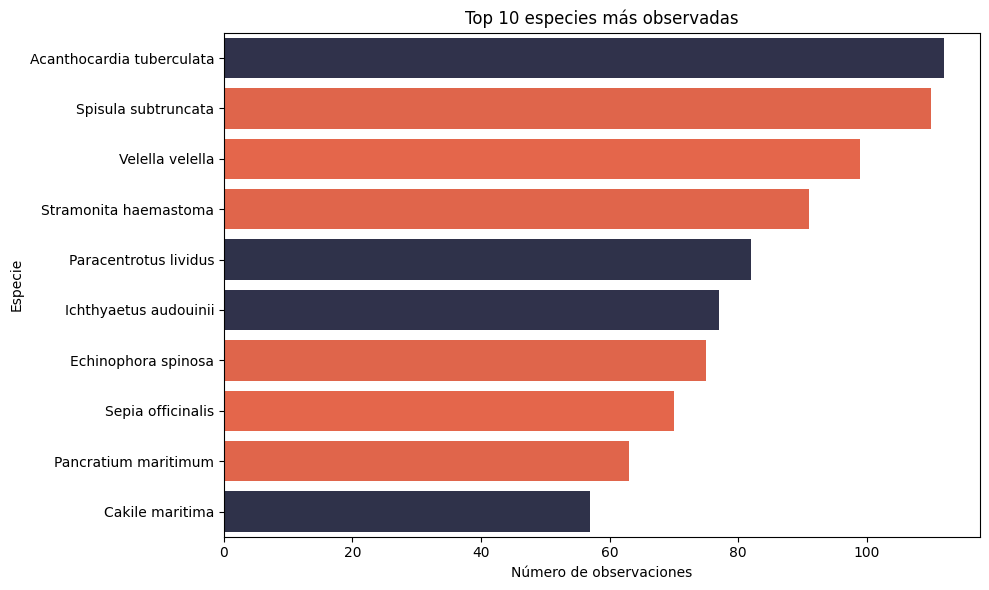

In [23]:

df_taxon_count = pd.read_csv(taxon_counts_path)
species_df = df_taxon_count[df_taxon_count['taxon_rank'] == 'species']

top_species = (
    species_df.groupby('taxon_name')['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_species, y='taxon_name', x='count', palette=palette)
plt.title('Top 10 especies más observadas')
plt.xlabel('Número de observaciones')
plt.ylabel('Especie')
plt.tight_layout()
plt.show()


# 5. Mapa calor para densidad de observaciones

In [ ]:
def get_heatmap(zoom_start:int):

    csv_obs = pd.read_csv(observations_path)

    df_valid = csv_obs.dropna(subset=["latitude", "longitude"])
    heat_data = df_valid[["latitude", "longitude"]].values.tolist()

    mean_lat = df_valid["latitude"].mean()
    mean_lon = df_valid["longitude"].mean()
   

    m = folium.Map(location=[mean_lat, mean_lon], zoom_start=zoom_start)
    HeatMap(heat_data).add_to(m)

    os.makedirs("figures", exist_ok=True)

    html_path = "figures/heatmap.html"
    m.save(html_path)

    img_data = m._to_png(3)
    img = Image.open(io.BytesIO(img_data))
    
    img.save('figures/heatmap_image.png')

In [ ]:
get_heatmap(11)